<a href="https://colab.research.google.com/github/Engr-Nauman/Irrigation-Requirement-XGBoost/blob/main/Irrigation_Predictor_for_Soil_(40%2B_features).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/irrigation-water-requirement-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'irrigation-water-requirement-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/irrigation-water-requirement-prediction-dataset


In [2]:
#Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# Loading the dataset into data frame
data_file = os.path.join(path, 'irrigation_prediction.csv')

df = pd.read_csv(data_file)

In [4]:
# Inspect the dataset
display(df.head())

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

There are 11 numerical data and 9 categorical data columns in the dataframe.
Let's check for missing or NULL values.

In [6]:
# Let's check the shape of dataset
print(df.shape)

(10000, 20)


In [7]:
print(df.isnull().sum())

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


Data is clean and doesn't have NULL values.

### Correlation Analysis for Numerical Features

Highly correlated features often provide redundant information. We can remove one of the highly correlated features to simplify the model without significant loss of information. Let's visualize the correlation matrix for our numerical features.

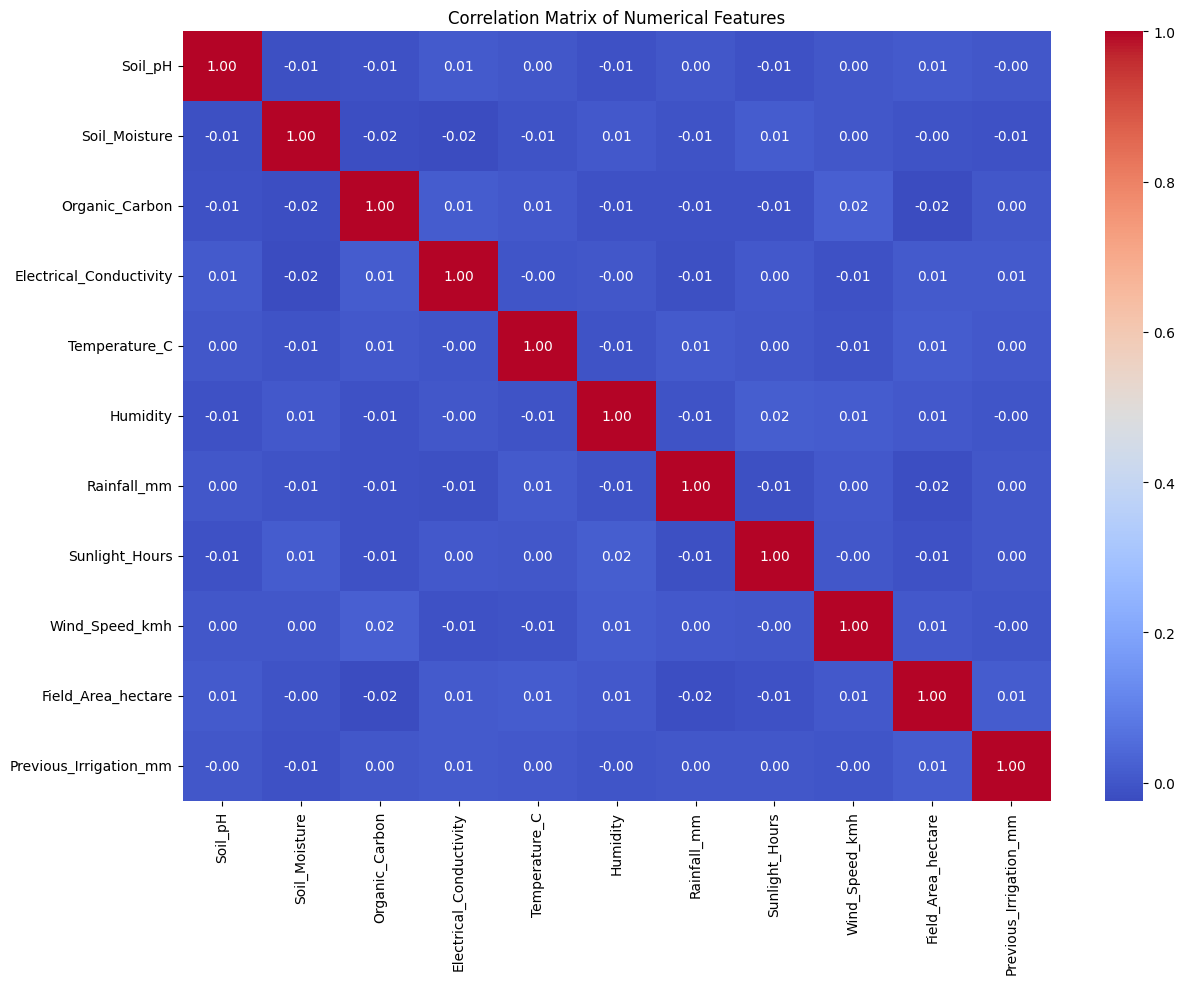

In [8]:
# Select only numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [9]:
#There is very less chance of co-relation
#between the numeric features.

#Let's convert the
## Categorical features into numerical

# We will take help of AI to generate code
# in colab for this

### One-Hot Encoding for Categorical Features

Categorical features, which represent distinct groups or labels, need to be converted into a numerical format so that machine learning algorithms can process them. One-hot encoding is a widely used method for this transformation. It creates a new binary column for each unique category within a feature. If a row belongs to a particular category, the corresponding column gets a `1`, and all other category columns for that feature get a `0`.

Let's apply one-hot encoding to our categorical features.

In [10]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns from the original df for encoding
categorical_cols = df.select_dtypes(include='object').columns

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply one-hot encoding to categorical features
encoded_features = encoder.fit_transform(df[categorical_cols])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns from df_final and concatenate with encoded_df
df_processed = df.drop(columns=categorical_cols)
df_processed = pd.concat([df_processed, encoded_df], axis=1)

print(f"Shape of DataFrame after one-hot encoding: {df_processed.shape}")
display(df_processed.head())

Shape of DataFrame after one-hot encoding: (10000, 46)


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West,Irrigation_Need_High,Irrigation_Need_Low,Irrigation_Need_Medium
0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,4.73,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,12.22,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,5.52,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,1.43,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,2.52,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


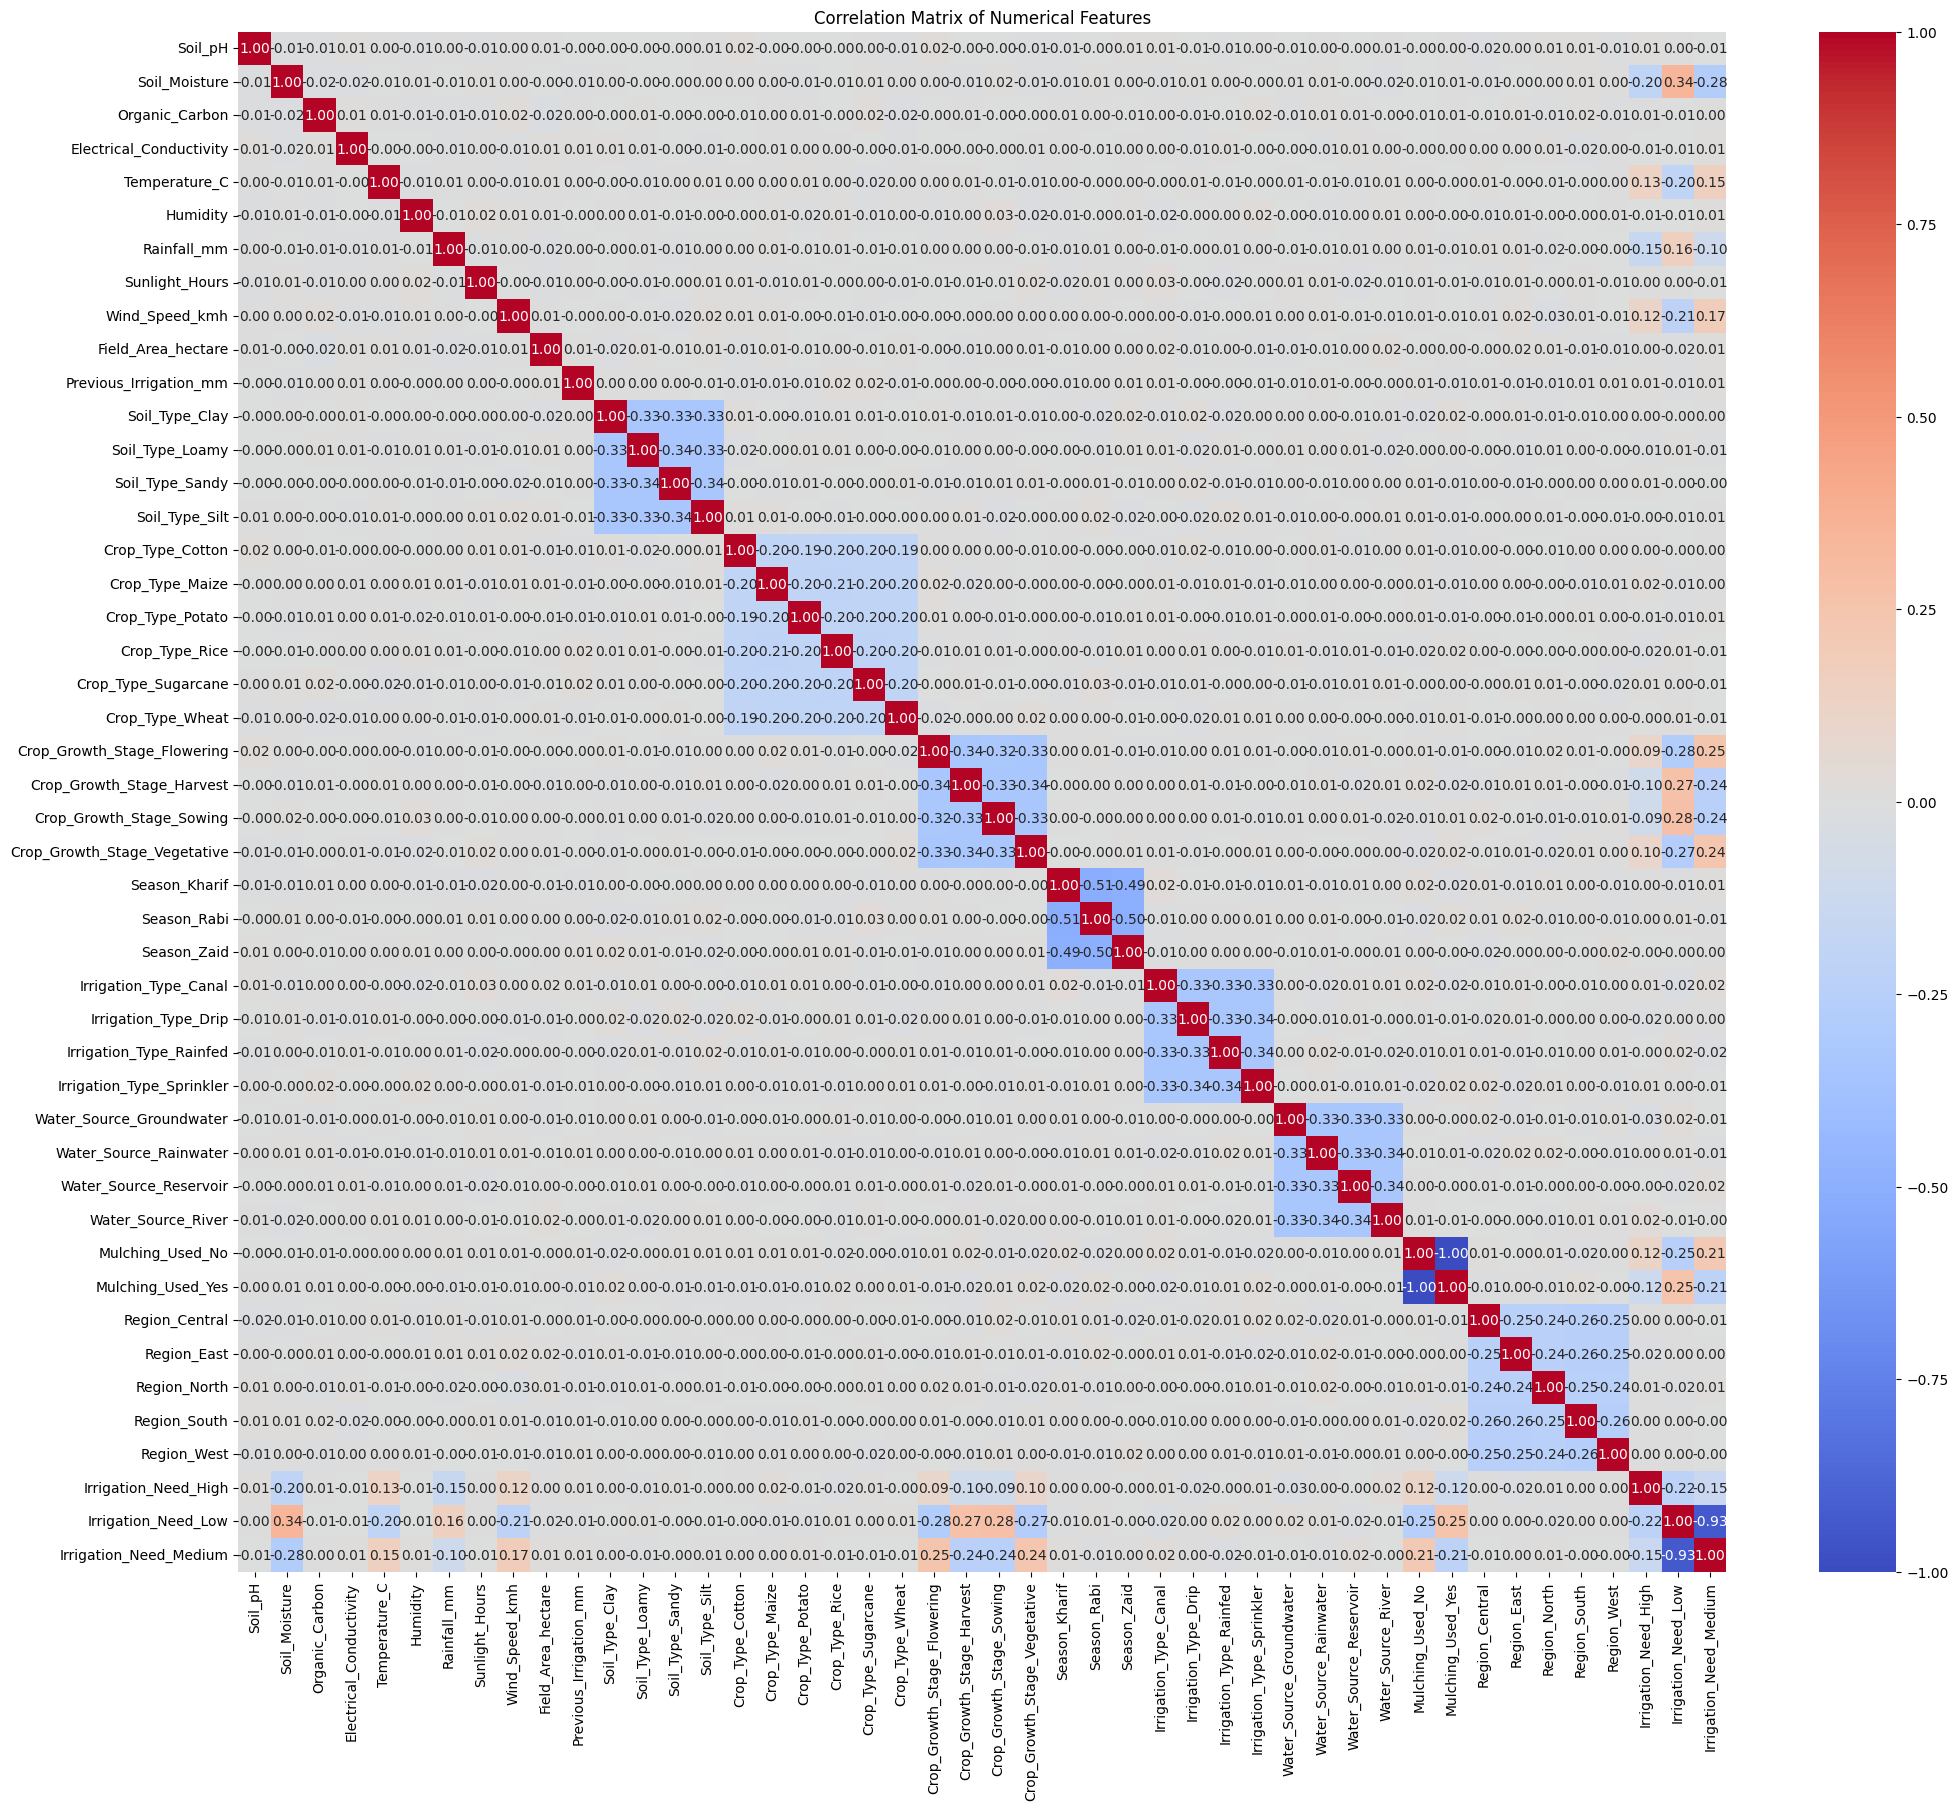

In [11]:
#Now again visualize the corelation matrix
correlation_matrix = df_processed.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

current_feature_df = df_processed.copy()

print(f"Shape of feature DataFrame before splitting (current_feature_df):{current_feature_df.shape}\n")

Shape of feature DataFrame before splitting (current_feature_df):(10000, 46)



In [30]:
# Reconstruct the target variable 'Irrigation_Need' from the one-hot encoded columns
# Identify the 'Irrigation_Need' related columns that are present in df_processed
irrigation_ohe_cols = [col for col in df_processed.columns if col.startswith('Irrigation_Need_')]

# Create a temporary DataFrame for these columns
temp_irrigation_ohe_df = df_processed[irrigation_ohe_cols].copy()

# Find the column where the value is 1 for each row
# This directly gives us the label (e.g., 'Irrigation_Need_High')
# and then we can strip the prefix.
y_labels = temp_irrigation_ohe_df.idxmax(axis=1).str.replace('Irrigation_Need_', '')

print(f"Unique values in y_labels before encoding: {y_labels.unique()}")
print(f"Value counts in y_labels:\n{y_labels.value_counts()}\n")

# Label encode the target variable
le = LabelEncoder()
y = le.fit_transform(y_labels)

Unique values in y_labels before encoding: ['Low' 'Medium' 'High']
Value counts in y_labels:
Low       5864
Medium    3800
High       336
Name: count, dtype: int64



In [18]:
# Define features (X) by dropping the one-hot encoded 'Irrigation_Need' columns from current_feature_df
# These are the columns that represent the target variable and should not be in the features.
X = current_feature_df.drop(columns=irrigation_ohe_cols, errors='ignore')

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Target classes and their encoded values: {list(le.classes_)} -> {list(range(len(le.classes_)))}\n")

Shape of features (X): (10000, 43)
Shape of target (y): (10000,)
Target classes and their encoded values: ['High', 'Low', 'Medium'] -> [0, 1, 2]



In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

X_train shape: (8000, 43)
X_test shape: (2000, 43)
y_train shape: (8000,)
y_test shape: (2000,)



In [39]:
# Initialize and train the XGBoost Classifier
# Use 'objective = multi:softmax' for multi-class classification
# num_class should be the number of unique classes in y
# multi:softmax: our target variable Irrigation_Need has three distinct
## categories ('High', 'Low', 'Medium'), this is the appropriate objective.
# eval_metric='mlogloss': a common metric for multiclass classification problems
model = XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

print("XGBoost model training complete.\n")

XGBoost model training complete.



In [21]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [22]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9980

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.96      0.98        67
         Low       1.00      1.00      1.00      1173
      Medium       1.00      1.00      1.00       760

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [40]:
import joblib
import os

# Define a directory to save the model and encoder
model_dir = 'model_artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save the trained XGBoost model
model_path = os.path.join(model_dir, 'xgboost_model.joblib')
joblib.dump(model, model_path)
print(f"Trained XGBoost model saved to: {model_path}")

# Save the LabelEncoder (le)
label_encoder_path = os.path.join(model_dir, 'label_encoder.joblib')
joblib.dump(le, label_encoder_path)
print(f"LabelEncoder saved to: {label_encoder_path}")

# Save the OneHotEncoder (encoder) used for original categorical features
# This is crucial for consistent encoding in the Streamlit app
encoder_path = os.path.join(model_dir, 'one_hot_encoder.joblib')
joblib.dump(encoder, encoder_path)
print(f"OneHotEncoder saved to: {encoder_path}")

# Save the list of feature columns used for training (X.columns)
# This ensures the input DataFrame in Streamlit has the exact same columns and order
feature_columns_path = os.path.join(model_dir, 'feature_columns.joblib')
joblib.dump(X.columns.tolist(), feature_columns_path)
print(f"Feature column names saved to: {feature_columns_path}")

print("\nAll necessary model artifacts have been saved.")


Trained XGBoost model saved to: model_artifacts/xgboost_model.joblib
LabelEncoder saved to: model_artifacts/label_encoder.joblib
OneHotEncoder saved to: model_artifacts/one_hot_encoder.joblib
Feature column names saved to: model_artifacts/feature_columns.joblib

All necessary model artifacts have been saved.
